# 1. Getting the Data Ready
### Stage 1 of 7 — cleaning the raw eye-tracking recordings

---

**How to read this notebook:** This is part of a 7-notebook series that walks through the *entire* research project, step by step, in the same order the actual analysis was done — this one covers stage 1 of 7. Every number and chart here is real, pulled directly from the study's actual data (130 students, 13 puzzles). A few small grey boxes contain code — you don't need to understand the code itself, just run each one (click it, then press Shift+Enter) to see the real result. Nothing needs to be edited.

---

## Overview

Every one of the 130 students' sessions produced two files straight out of the eye-tracking software (called Tobii Pro Lab):

| File | What's in it |
|---|---|
| **The Metrics file** | Already-summarised numbers — for every student, for every puzzle, for every "zone" on the picture: how long they looked there, how many times, etc. (39,000 rows) |
| **The Data export file** | The *raw* stream — every single measurement the eye tracker took, about **120 times a second**, for the whole session. (**4,538,514 rows** — over 4.5 million!) |

Before any of the interesting analysis can happen, both files need cleaning. This notebook is about that unglamorous but essential first step — the eye-tracking equivalent of washing vegetables before cooking.

## What You'll Learn Here

1. Why raw sensor data almost always needs cleaning before you can trust it
2. What a "placeholder" value is, and why eye trackers write them
3. How to tell whether a recording is good enough quality to use
4. Why matching up two files by student name is trickier than it sounds
5. Why a file with 4.5 million rows can't always just be opened normally

## Background, Explained Simply

### Why does raw data need cleaning?

Think about it like this: if you asked 130 people to fill out a form by hand, some would leave boxes blank, some would write illegibly, and a couple would probably use a different unit of measurement by mistake. A computer collecting data automatically has the exact same problem, just at a much larger scale and much faster.

For eye trackers specifically, the biggest cause of messy data is simply **blinking** — every time someone blinks, the camera can't see their eye for a fraction of a second, so it has nothing to record. Head movements and looking away from the screen cause similar gaps.

### "Placeholder" values

When the eye tracker can't measure something, it doesn't leave the cell truly blank — it writes a placeholder symbol (a dash, `-`) instead. If you don't specifically tell the analysis software "a dash means *no data*, not *literally zero*," it can badly skew your results — imagine averaging in a bunch of dashes as if they were zeroes.

### How do we know if a recording is "good enough"?

For every student, we calculate: *out of every measurement the eye tracker attempted, what percentage actually produced a usable eye position?* We call this the **valid gaze rate**. This study used a common rule of thumb: **keep the recording if at least 70% of measurements were valid** — below that, there's reason to worry the numbers no longer reflect what the person was actually doing.

### Why a 3-gigabyte file needs special handling

The raw Data export file is enormous — 4.5 million rows and, in its original form, over 240 columns (most of them things this study didn't need, like exact monitor calibration details). Trying to load all of that into a computer's memory in one go can simply run out of space and crash. The fix is straightforward once you know the trick: **only load the columns you actually need**, and read the file in smaller batches rather than all at once — like carrying groceries in from the car a few bags at a time instead of trying to grab everything in one trip.

## Discussion Questions

1. If a student blinked constantly during one puzzle, would you trust their data for that puzzle? What would you want to know before deciding?
2. Why might treating a "no data" placeholder as if it were a real "zero" measurement be misleading — can you think of a concrete example where this would give a wrong answer?
3. The 70% cutoff is a judgment call, not a law of nature. What would happen to the study if the cutoff were much stricter (say, 95%)? What would happen if it were much looser (say, 40%)?
4. Two files need to be matched up by student name. What could go wrong if one file has "Student 1" and the other has "student1 " (with a trailing space)? How would you prevent that?

---

## Seeing the Real Result

Every one of the 130 students' recordings was checked against the 70% cutoff. Here's what that actually looked like, student by student (the red dashed line marks the cutoff):

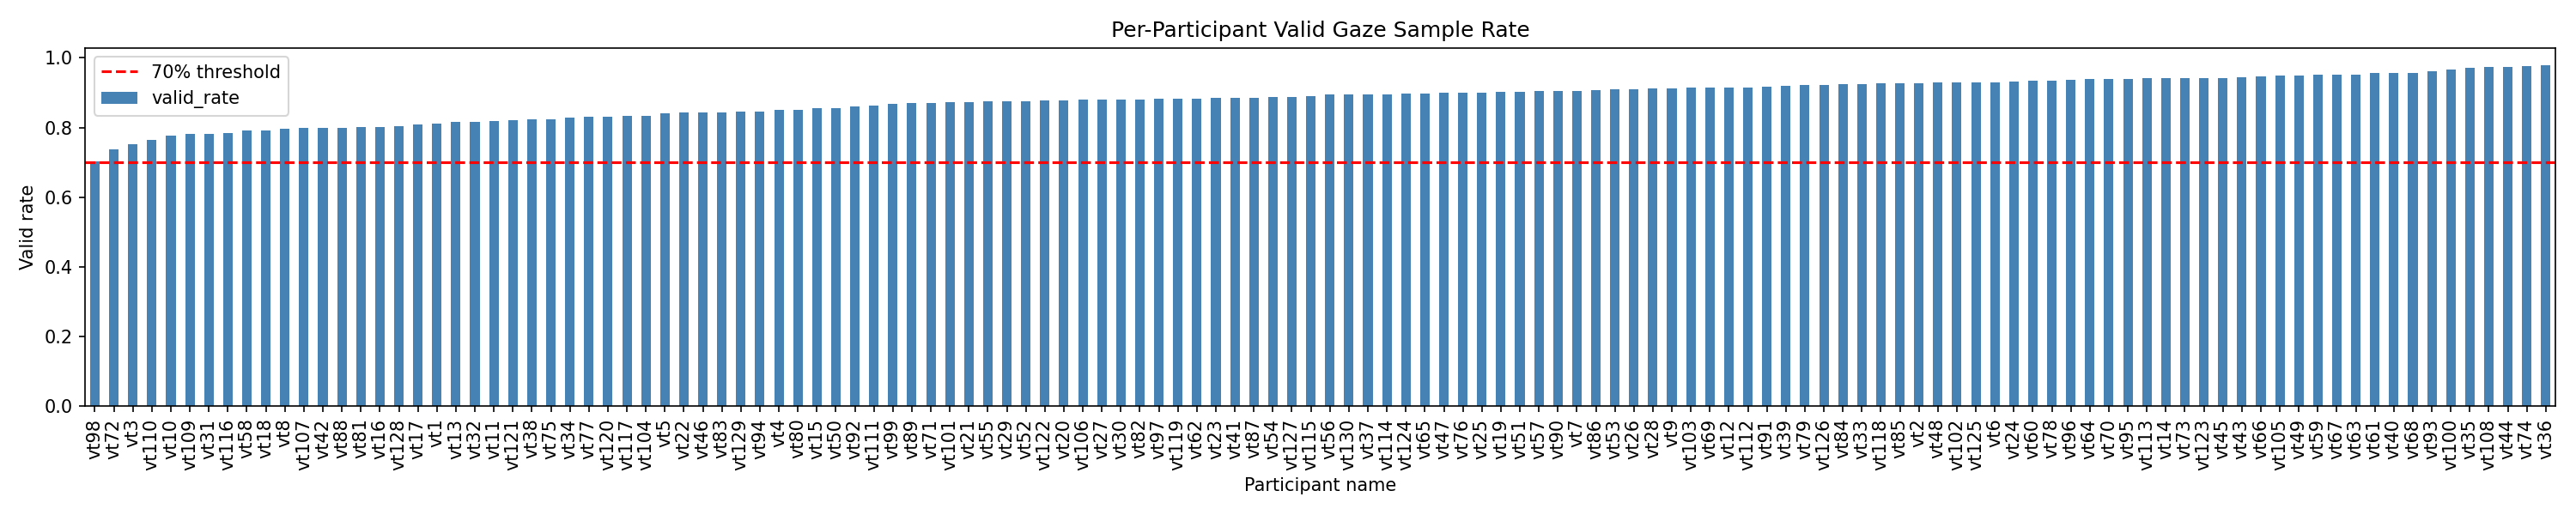

In [1]:
# Run this cell to see the real data-quality check across all 130 students
from IPython.display import Image
Image(filename='../outputs/figures/01_gaze_quality.png')

**The real result: every single one of the 130 students cleared the bar.** The lowest was 70.2% — just barely above the cutoff — and the highest students had well over 95% valid data. Nobody had to be excluded from the study for poor data quality.

## What Actually Happened, By the Numbers

- The Metrics file: **39,000 rows**, all usable.
- The Data export file: **4,538,514 rows** — but only **154 of the original 240+ columns** were actually needed (participant name, which puzzle was on screen, gaze position, pupil size, and which "zone" the eyes were in), which is what made loading it manageable.
- After cleaning, the two files were checked against each other by student name — a **perfect match**: all 130 students appeared in both files, with no typos or mismatches to fix.
- Both cleaned files were saved in a format called **Parquet** rather than the more familiar CSV/Excel format — think of it as a more efficient "zip file for data tables": faster to load, and it remembers what type of data is in each column (so no re-guessing needed every time it's opened).

---

**Next: [02_turning_looks_into_numbers.ipynb](02_turning_looks_into_numbers.ipynb)** — now that the raw data is trustworthy, how do we turn 4.5 million individual eye positions into a handful of meaningful measurements per student?